# Results

# Viewing Results

In [1]:
import json

def load_probability_model(path):
    with open(path, "r", encoding="utf-8") as f:
        model = json.load(f)
    return model

## Perplexity

Metric that measures the uncertainty of a model's predictions. Specifically, in language models, it quantifies how well the model predicts the next word in a sequence. When a model makes a prediction, it assigns probabilities to possible next words.

Let $w_1, w_2, \dots, w_T$ be a sequence of words in the test set.
The perplexity of an $n$-gram language model is defined as:

$$
\text{Perplexity}
= \exp\left(
-\frac{1}{T}
\sum_{t=1}^{T}
\log P\!\left(
w_t \mid w_{t-(n-1)}, \dots, w_{t-1}
\right)
\right)
$$

GeeksforGeeks. (2025, July 23). Perplexity for LLM evaluation. https://www.geeksforgeeks.org/nlp/perplexity-for-llm-evaluation/ 

**Where:**

- $T$ is the total number of tokens (words) in the sentence.

- $w_t$ denotes the word at position $t$ in the sentence.

- $n$ is the order of the N-gram model (e.g., $n = 1$ for a unigram model, $n = 2$ for a bigram model).

- $(w_{t-n+1}, \ldots, w_{t-1})$ represents the $(n-1)$-word context preceding the word $w_t$.

- $P(w_t \mid w_{t-n+1}, \ldots, w_{t-1})$ is the conditional probability assigned by the N-gram model to the word $w_t$ given its preceding context.

- $\sum_{t=1}^{T}$ indicates that the log-probabilities are summed over all word positions in the sentence.

- $\log(\cdot)$ is used to convert the product of probabilities into a sum, which improves numerical stability and interpretability.


In [2]:
import json
from math import log, exp 
import pandas as pd

# Function to compute the perplexity of an n-gram model on a test dataset where n is the order of the n-gram model, test_csv is the path to the CSV file containing the test n-grams, prob_dicts is a dictionary of probability models for different n values, and epsilon is a small value to avoid log(0)

def compute_perplexity(test_csv, prob_dicts, n, sample_frac, epsilon=1e-12):
    df = pd.read_csv(test_csv)
    log_prob_sum = 0.0
    T = 0

    if sample_frac < 1.0:
        df = df.sample(frac=sample_frac, replace=False, random_state=None) # fraction of data to sample, the sample is different each time as random_state is None

    model = prob_dicts[n]

    for ngram_str in df["N-gram"]:
        ngram = eval(ngram_str)  # ['w1','w2',...]
        target = ngram[-1]

        if n == 1:
            context = "()"
        else:
            context = str(tuple(ngram[:-1]))

        prob = model.get(context, {}).get(target, epsilon) # if the model assigns zero probability, pretend it is very small instead

        log_prob_sum += log(prob)
        T += 1

    return exp(-log_prob_sum / T)

In [ ]:
import numpy as np

modeltype = {"word", "character"}
category = "all"  # "business", "entertainment", "politics", "sport", "tech", "all"

N = [1, 2, 3, 4, 5]
num_runs = 10
sample_frac = 0.8  # fixed size, random subsample each run

# Store results as: runs × n
perplexities_word = np.zeros((num_runs, len(N)))
perplexities_char = np.zeros((num_runs, len(N)))

for run in range(num_runs):
    prob_dicts_word = {}
    prob_dicts_char = {}

    for mt in modeltype:
        for i, n in enumerate(N):
            test_file = f"./../Dataset_NGrams/bbc_{mt}_{n}grams_test.csv"
            path = f"./../Probability_NGrams/{mt}_{n}grams_{category}_probability.json"

            if mt == "word":
                prob_dicts_word[n] = load_probability_model(path)
                ppl_word = compute_perplexity(
                    test_file,
                    prob_dicts_word,
                    n,
                    sample_frac=sample_frac
                )
                perplexities_word[run, i] = ppl_word

            else:  # character
                prob_dicts_char[n] = load_probability_model(path)
                ppl_char = compute_perplexity(
                    test_file,
                    prob_dicts_char,
                    n,
                    sample_frac=sample_frac
                )
                perplexities_char[run, i] = ppl_char

# Sample Runs & Averages

To obtain robust perplexity estimates, evaluation was repeated 10 times using random subsampling of 80% of the test n-grams. Final results are reported as the mean perplexity across runs, with standard deviation indicating variability.

In [4]:
avg_word = perplexities_word.mean(axis=0) # average over runs, method from numpy
std_word = perplexities_word.std(axis=0) # standard deviation over runs, method from numpy

avg_char = perplexities_char.mean(axis=0)
std_char = perplexities_char.std(axis=0)

print("Average perplexities for word N-grams:", avg_word)
print("Average perplexities for character N-grams:", avg_char)

Average perplexities for word N-grams: [1.77255507e+03 1.14591584e+04 4.32847988e+06 1.58215773e+08
 5.71686754e+08]
Average perplexities for character N-grams: [22.34567038 12.23206567  7.69963851  5.37722915  5.54212059]


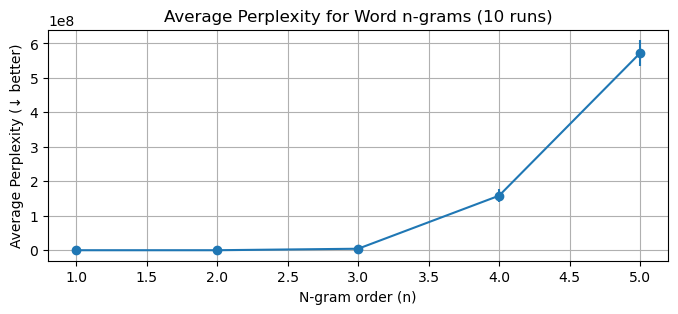

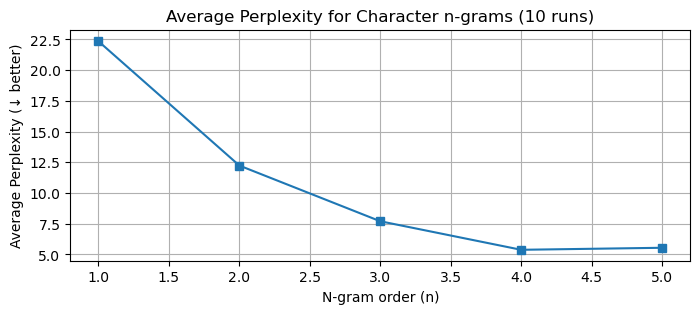

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.errorbar(N, avg_word, yerr=std_word, marker='o')
plt.xlabel("N-gram order (n)")
plt.ylabel("Average Perplexity (↓ better)")
plt.title("Average Perplexity for Word n-grams (10 runs)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 3))
plt.errorbar(N, avg_char, yerr=std_char, marker='s')
plt.xlabel("N-gram order (n)")
plt.ylabel("Average Perplexity (↓ better)")
plt.title("Average Perplexity for Character n-grams (10 runs)")
plt.grid(True)
plt.show()

As the N-gram order increases, perplexity rises sharply. This behavior is expected due to data sparsity: higher-order N-gram models rely on increasingly specific contexts, many of which do not appear in the training data. As a result, the model assigns very low probabilities to test sequences, leading to large perplexity values. Without smoothing or backoff techniques, higher-order models tend to generalize poorly to unseen data despite being more expressive.

## N-gram Accuracy

For each N-gram order, we run the model on testing sentences and measure how often the generated continuation matches the true continuation in the test set. Through this measurement we try to answer: "Does the model’s predicted next word match the actual next word in the dataset?"

$$
\text{Accuracy}_n
=
\frac{
\text{Number of correct next-word predictions}
}{
\text{Total number of predictions}
}
$$

In [12]:
import json
from ast import literal_eval
import os 

sourcefolder = f"./../Probability_NGrams/"
categories = {"business", "entertainment", "politics", "sport", "tech", "all"}	
prob_dicts_char = [{}]
prob_dicts_word = [{}]
prob_json = [""]  # Start with a dummy entry for 0-grams to align indices

# Read in JSON probability file(s) and catch non-existing files
for k in range(1, n+1):
	json_path = f"{sourcefolder}word_{k}grams_all_probability.json"
	if not os.path.exists(json_path):
		print(f"Skipping (file not found): {json_path}")
		continue
		
	with open(json_path, "r", encoding="utf-8") as f:
		#print(f"Loading: {json_path}")
		dictionary = json.load(f)
		prob_json.append(dictionary)

for k in range(1, n+1):
	prob_dict = {}
	for prefix_str, next_tokens in prob_json[k].items():
		prefix = literal_eval(prefix_str)
		prob_dict[prefix] = {}
		for token, prob in next_tokens.items():
			prob_dict[prefix][token] = prob
	prob_dicts_word.append(prob_dict)

In [6]:
import random

def sample_next_token(prob_dicts, sequence, n):
	prefix = ()
	# Get the current prefix (last n-1 words)
	if n > 1:
		prefix = tuple(sequence[-(n-1):])

	# In the probability dictionary, get possible next tokens for the given prefix
	next_tokens = prob_dicts[n].get(prefix, {})
	
	# If no next tokens found, back off to (n-1)-gram model
	if next_tokens == {}:
		return sample_next_token(prob_dicts, sequence, n-1)				# RECURSION: try with n-1-gram
	
	words = list(next_tokens.keys())
	probs = list(next_tokens.values())
	
	next_token = random.choices(words, weights=probs, k=1)[0]
	#print(f"Current n: {n}, Current prefix: {prefix}, Next token: {next_token} ")
	return next_token

In [7]:
# Function to evaluate next-word prediction accuracy of an n-gram model where prob_model is the probability model, test_sentence is the tokenized reference sentence, and n is the n-gram order

def evaluate_next_word_accuracy(prob_dicts, test_sentence, n):
    correct = 0
    total = 0

    for i in range(len(test_sentence) - n + 1):
        ngram = test_sentence[i : i + n]
        context_words = ngram[:-1]
        true_next_word = ngram[-1]

        predicted_word = sample_next_token(
            prob_dicts=prob_dicts,
            sequence=context_words,
            n=n
        )

        print(f"Context: {context_words} | True: {true_next_word} | Predicted: {predicted_word}")

        correct += int(predicted_word == true_next_word)
        total += 1

    accuracy = correct / total if total > 0 else 0.0
    return accuracy


In [8]:
import pandas as pd
from ast import literal_eval

# 
def load_test_sentence(csv_path, sample_frac=0.8, prob_dicts=None, n=None):
    correct = 0
    total = 0

    df = pd.read_csv(csv_path)

    df_sample = df.sample(frac=sample_frac, random_state=None).reset_index(drop=True) # random sample of rows from the CSV file, different each time as random_state is None

    #first_ngram = literal_eval(df_sample.iloc[0]["N-gram"]) # convert the string representation of the n-gram back to a list, where iloc[0] gets the first row of the sampled dataframe and "N-gram" is the column name containing the n-grams
    
    for ngram_str in df_sample["N-gram"]:
		# literal_eval converts "['I','am','very']" → ['I','am','very']
        ngram = literal_eval(ngram_str)

        prefix = tuple(ngram[:-1])   	# all except last element
        next_token = ngram[-1]       	# last element

        next_token_model = sample_next_token(prob_dicts, prefix, n)

        correct += int(next_token_model == next_token)
        total += 1
    
    accuracy = correct / total if total > 0 else 0.0

    return accuracy

In [13]:
import numpy as np

modeltypes = ["word", "character"]
N = [1, 2, 3, 4, 5]
num_runs = 1

accuracy_word_runs = {n: [] for n in N}
accuracy_char_runs = {n: [] for n in N}

for run in range(num_runs):
    for n in N:

        # WORD MODEL
        word_path = f"./../Dataset_NGrams/bbc_word_{n}grams_test.csv"
        word_accuracy_run = load_test_sentence(word_path, 0.8, prob_dicts_word, n=n)
        accuracy_word_runs[n].append(word_accuracy_run)

        # CHARACTER MODEL
        #character_path = f"./../Dataset_NGrams/bbc_character_{n}grams_test.csv"
        #char_accuracy_run = load_test_sentence(character_path, 0.8, prob_dicts=prob_dicts_char,n=n)
        #accuracy_char_runs[n].append(char_accuracy_run)

IndexError: list index out of range

In [ ]:
avg_word_acc = [np.mean(accuracy_word_runs[n]) for n in N]
std_word_acc = [np.std(accuracy_word_runs[n]) for n in N]

avg_char_acc = [np.mean(accuracy_char_runs[n]) for n in N]
std_char_acc = [np.std(accuracy_char_runs[n]) for n in N]

print("Average accuracies for word N-grams:", avg_word_acc)
print("Average accuracies for character N-grams:", avg_char_acc)

print("Average standard deviations for word N-grams:", std_word_acc)
print("Average standard deviations for character N-grams:", std_char_acc)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.errorbar(N, avg_word_acc, yerr=std_word_acc, marker='o', color='deeppink')
plt.ylim(min(avg_word_acc), max(avg_word_acc) * 1.25)
plt.xlabel("N-gram order (N)")
plt.ylabel("Average Accuracy")
plt.title("Next-word Prediction Accuracy (Word n-grams)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 3))
plt.errorbar(N, avg_char_acc, yerr=std_char_acc, marker='s', color='deeppink')
plt.xlabel("N-gram order (N)")
plt.ylabel("Average Accuracy")
plt.ylim(min(avg_char_acc), max(avg_char_acc) * 1.25)
plt.title("Next-character Prediction Accuracy (Character n-grams)")
plt.grid(True)
plt.show()

Perplexity evaluates how well an N-gram model predicts the test data, while N-gram overlap measures how closely generated sequences resemble the empirical N-grams in the dataset. Lower perplexity indicates better generalization, whereas higher overlap reflects closer adherence to observed patterns.

## Results by Category

### Given test data from ONE category, which trained model predicts it best?

In [ ]:
import pandas as pd
from ast import literal_eval

def evaluate_ngram_accuracy_by_category(test_csv_path, prob_model, n, target_category):
    df = pd.read_csv(test_csv_path)
    df_cat = df[df["Category"] == target_category]

    correct = 0
    total = 0

    for ngram_str in df_cat["N-gram"]:
        ngram = literal_eval(ngram_str)

        if len(ngram) != n:
            continue

        context = str(tuple(str(tok) for tok in ngram[:-1]))
        true_next = str(ngram[-1])

        predicted = max(
            prob_model[context],
            key=prob_model[context].get
        )

        correct += int(predicted == true_next)
        total += 1

    return correct / total if total > 0 else 0.0

In [ ]:
test_csv = "./../Dataset_NGrams/bbc_word_4grams_test.csv"

model_paths = {
    "business": "./../Probability_NGrams/word_4grams_business_probability.json",
    "entertainment": "./../Probability_NGrams/word_4grams_entertainment_probability.json",
    "politics": "./../Probability_NGrams/word_4grams_politics_probability.json",
    "sport": "./../Probability_NGrams/word_4grams_sport_probability.json",
    "tech": "./../Probability_NGrams/word_4grams_tech_probability.json",
    "all": "./../Probability_NGrams/word_4grams_all_probability.json"
}

models = {
    name: load_probability_model(path)
    for name, path in model_paths.items()
}

In [ ]:
test_csv_character = "./../Dataset_NGrams/bbc_character_4grams_test.csv"

model_paths_character = {
    "business": "./../Probability_NGrams/character_4grams_business_probability.json",
    "entertainment": "./../Probability_NGrams/character_4grams_entertainment_probability.json",
    "politics": "./../Probability_NGrams/character_4grams_politics_probability.json",
    "sport": "./../Probability_NGrams/character_4grams_sport_probability.json",
    "tech": "./../Probability_NGrams/character_4grams_tech_probability.json",
    "all": "./../Probability_NGrams/character_4grams_all_probability.json"
}

models_character = {
    name: load_probability_model(path)
    for name, path in model_paths.items()
}

In [ ]:
n = 4
num_runs = 10

test_categories = ["business", "entertainment", "politics", "sport", "tech"]
model_categories = ["business", "entertainment", "politics", "sport", "tech", "all"]

### Word model

accuracy_runs = {
    test_cat: {model_cat: [] for model_cat in model_categories}
    for test_cat in test_categories
}

for _ in range(num_runs):
    for test_cat in test_categories:
        for model_cat in model_categories:
            acc = evaluate_ngram_accuracy_by_category(
                test_csv_path=test_csv,
                prob_model=models[model_cat],
                target_category=test_cat,
                n=n
            )
            accuracy_runs[test_cat][model_cat].append(acc)

avg_accuracy = {
    test_cat: {
        model_cat: np.mean(accuracy_runs[test_cat][model_cat])
        for model_cat in model_categories
    }
    for test_cat in test_categories
}

### Character model

accuracy_runs_character = {
    test_cat: {model_cat: [] for model_cat in model_categories}
    for test_cat in test_categories
}

for _ in range(num_runs):
    for test_cat in test_categories:
        for model_cat in model_categories:
            acc = evaluate_ngram_accuracy_by_category(
                test_csv_path_character=test_csv_character,
                prob_model_character=models_character[model_cat],
                target_category=test_cat,
                n=n
            )
            accuracy_runs_character[test_cat][model_cat].append(acc)

avg_accuracy_character = {
    test_cat: {
        model_cat: np.mean(accuracy_runs_character[test_cat][model_cat])
        for model_cat in model_categories
    }
    for test_cat in test_categories
}


In [ ]:
df_heatmap = pd.DataFrame(avg_accuracy).T  

plt.figure(figsize=(10, 5))
plt.imshow(df_heatmap, aspect="auto", cmap="twilight_shifted",)
plt.colorbar(label="Average Accuracy")

plt.xticks(
    range(len(df_heatmap.columns)),
    df_heatmap.columns,
    rotation=45
)
plt.yticks(
    range(len(df_heatmap.index)),
    df_heatmap.index
)

plt.xlabel("Model training category")
plt.ylabel("Test data category")
plt.title("Word 4-gram Accuracy by Test Category vs Model Category")

for i in range(df_heatmap.shape[0]):
    for j in range(df_heatmap.shape[1]):
        plt.text(
            j,
            i,
            f"{df_heatmap.iloc[i, j]:.3f}",
            ha="center",
            va="center",
            color="white",
            fontsize=9
        )

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

colors = {
    "business": "#1f77b4",
    "entertainment": "#ff7f0e",
    "politics": "#2ca02c",
    "sport": "#d62728",
    "tech": "#9467bd",
    "all": "#8c564b"
}

for test_cat in test_categories:
    plt.figure(figsize=(6, 4))

    model_cats = list(avg_accuracy[test_cat].keys())
    accuracies = list(avg_accuracy[test_cat].values())

    bar_colors = [colors[cat] for cat in model_cats]

    bars = plt.bar(
        range(len(model_cats)),
        accuracies,
        color=bar_colors
    )

    plt.ylim(0, max(accuracies) * 1.25)
    plt.xlabel("Model category")
    plt.ylabel("Average Accuracy")
    plt.title(f"Word 4-gram Accuracy on {test_cat.capitalize()} Test Data")

    # Remove x-axis labels
    plt.xticks([])

    # Add accuracy values above bars
    for bar, acc in zip(bars, accuracies):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{acc:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    # Legend
    legend_handles = [
        Patch(color=colors[cat], label=cat)
        for cat in model_cats
    ]
    plt.legend(handles=legend_handles, title="Model category")

    plt.tight_layout()
    plt.show()